# SEM: Selective Search Segmentation

## ¿Qué es SEM (Selective Search Segmentation)?

**Selective Search** es un algoritmo de segmentación jerárquica basado en superpixels que fue diseñado originalmente para generación de propuestas de regiones en detección de objetos. Sin embargo, sus principios son aplicables a cualquier tarea de segmentación de imágenes.

### Funcionamiento del algoritmo:

1. **Superpixels iniciales**: El algoritmo comienza utilizando SLIC (Simple Linear Iterative Clustering) para generar superpixels iniciales basados en color y textura.

2. **Segmentación jerárquica**: 
   - Comienza con una segmentación sobre-segmentada (muchas regiones pequeñas)
   - Iterativamente fusiona regiones similares adyacentes
   - Construye un árbol jerárquico de regiones

3. **Criterios de similitud**: Usa múltiples criterios para fusionar regiones:
   - **Color**: Histogramas de color en espacio HSV
   - **Textura**: Histogramas de gradientes de textura (LBP-like)
   - **Tamaño**: Preferencia por fusionar regiones pequeñas primero
   - **Forma**: Compatibilidad de forma (relleno)

4. **Propuestas múltiples**: Genera múltiples segmentaciones en diferentes escalas, capturando objetos de diferentes tamaños

### Aplicación en imágenes retinales:

En imágenes de fondo de ojo (retinal), Selective Search puede ayudar a:
- Identificar regiones de interés (disco óptico, mácula, lesiones)
- Pre-procesar para sistemas de diagnóstico asistido por computadora
- Reducir el espacio de búsqueda para modelos de deep learning

In [4]:
# Importar librerías necesarias
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io, color, segmentation
from skimage.segmentation import felzenszwalb, slic, quickshift, watershed
from skimage.segmentation import mark_boundaries
import os
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para mostrar imágenes
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

## 1. Cargar una imagen retinal

Primero, carguemos una imagen del dataset de retinopatía diabética.

In [5]:
# Buscar imágenes disponibles
def find_images(base_path, extensions=['.jpeg', '.jpg', '.png']):
    """Encuentra todas las imágenes en un directorio y subdirectorios"""
    images = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                images.append(os.path.join(root, file))
    return images

# Cargar una imagen de ejemplo
data_path = 'data/1-mild'
images = find_images(data_path)

if len(images) > 0:
    # Seleccionar una imagen
    img_path = images[10]
    print(f"Cargando imagen: {img_path}")
    
    # Leer con OpenCV (BGR -> RGB)
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr is not None else None
    
    if img_rgb is not None:
        print(f"Dimensiones: {img_rgb.shape}")
    else:
        print("Error al cargar la imagen")
else:
    print("No se encontraron imágenes")

Cargando imagen: data/1-mild/2802_right.jpeg
Dimensiones: (1920, 2560, 3)


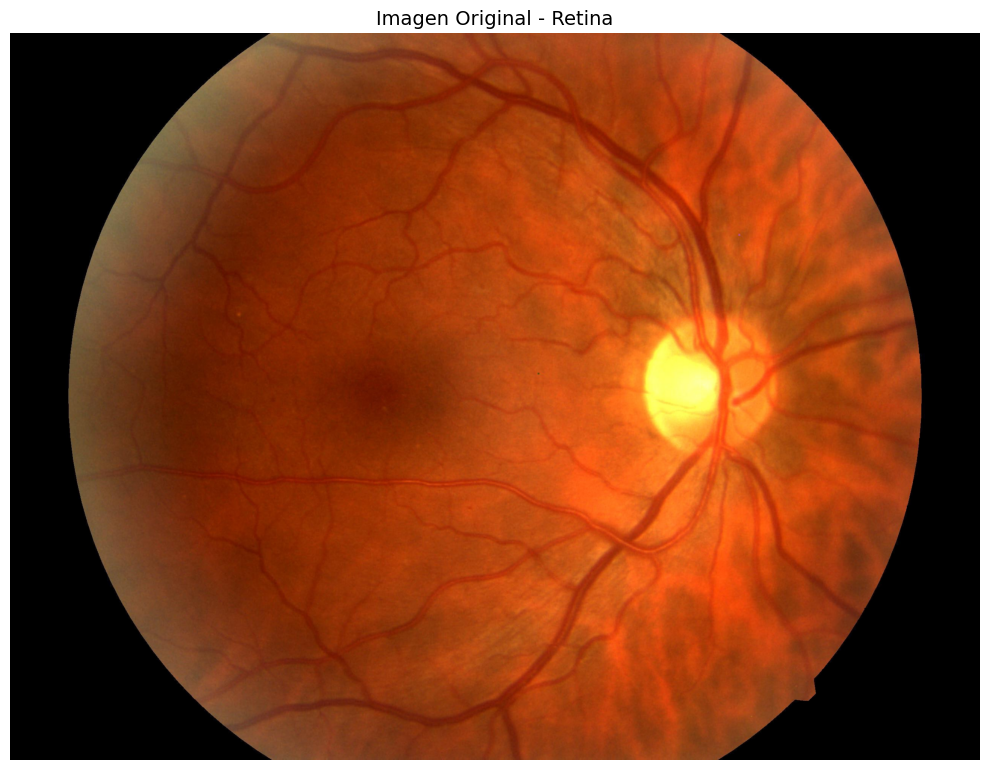

In [6]:
# Mostrar la imagen original
if img_rgb is not None:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_rgb)
    ax.set_title('Imagen Original - Retina', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 2. Preprocesamiento de la imagen

Antes de aplicar SEM, es útil preprocesar la imagen para mejorar los resultados de segmentación.

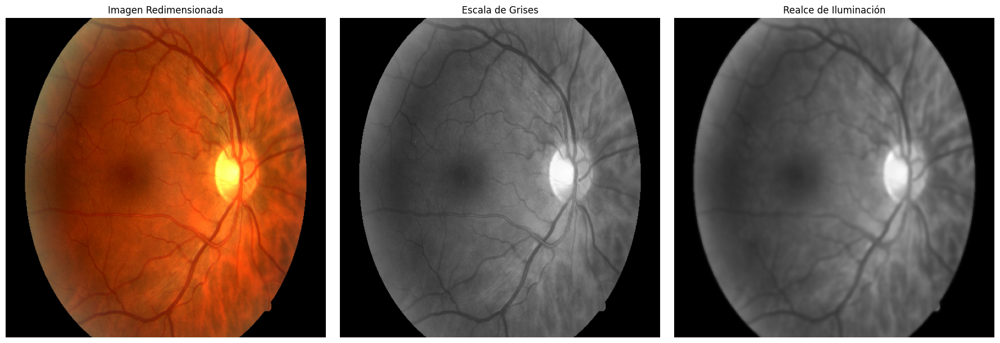

In [7]:
# Preprocesamiento
def preprocess_retinal_image(img):
    """
    Preprocesa una imagen retinal para mejorar la segmentación.
    
    Pasos:
    1. Redimensionar a un tamaño fijo para consistencia
    2. Aplicar corrección de iluminación (top-hat)
    3. Suavizar para reducir ruido
    """
    # Redimensionar
    img_resized = cv2.resize(img, (512, 512))
    
    # Convertir a escala de grises para procesamiento
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    
    # Aplicar filtro bilateral para suavizar preservando bordes
    blurred = cv2.bilateralFilter(gray, 9, 75, 75)
    
    # Top-hat para corregir iluminación no uniforme
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    tophat = cv2.morphologyEx(blurred, cv2.MORPH_TOPHAT, kernel)
    
    # Combinar imagen original con top-hat
    enhanced = cv2.addWeighted(blurred, 1, tophat, 0.5, 0)
    
    return img_resized, gray, enhanced

if img_rgb is not None:
    img_resized, gray_img, enhanced = preprocess_retinal_image(img_rgb)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_resized)
    axes[0].set_title('Imagen Redimensionada')
    axes[0].axis('off')
    
    axes[1].imshow(gray_img, cmap='gray')
    axes[1].set_title('Escala de Grises')
    axes[1].axis('off')
    
    axes[2].imshow(enhanced, cmap='gray')
    axes[2].set_title('Realce de Iluminación')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## 3. Implementación de SEM (Selective Search)

### 3.1 SLIC Superpixels (Base de SEM)

**SLIC (Simple Linear Iterative Clustering)** es el algoritmo fundamental usado en Selective Search para generar superpixels iniciales. Funciona así:

1. **Inicialización**: Divide la imagen en una cuadrícula de K superpixels equitativos
2. **Medias móviles**: Asigna cada píxel al centroide más cercano en el espacio 5D (L*a*b* + XY)
3. **Actualización**: Recalcula los centros de los clusters
4. **Iteración**: Repite los pasos 2-3 hasta convergencia

**Espacio de color LAB**: Usa el espacio CIEL*a*b* que es perceptualmente uniforme, lo que significa que las distancias euclidianas se corresponden con diferencias visuales reales.

Número de superpixels: 182


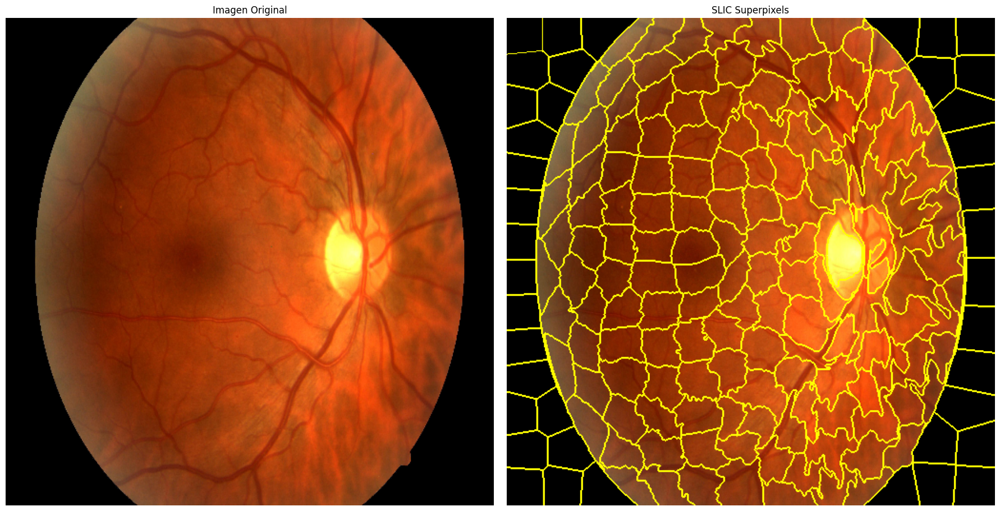

In [8]:
# 3.1 SLIC Superpixels - Base de SEM

def apply_slic_superpixels(img, n_segments=200, compactness=10.0):
    """
    Aplica SLIC superpixels a la imagen.
    
    Parámetros:
    - n_segments: Número aproximado de superpixels deseados
    - compactness: Balance entre color y posición espacial (mayor = más cuadrados)
    
    Retorna:
    - segments: Máscara de segmentación donde cada píxel tiene etiqueta de región
    """
    # Convertir a espacio RGB float
    img_float = img.astype(np.float64) / 255.0
    
    # Aplicar SLIC
    segments = slic(
        img_float,
        n_segments=n_segments,
        compactness=compactness,
        sigma=1,
        start_label=0,
        channel_axis=-1  # RGB
    )
    
    return segments

# Aplicar SLIC
if img_rgb is not None:
    segments_slic = apply_slic_superpixels(img_resized, n_segments=200, compactness=10.0)
    
    print(f"Número de superpixels: {len(np.unique(segments_slic))}")
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    
    axes[0].imshow(img_resized)
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    
    axes[1].imshow(mark_boundaries(img_resized, segments_slic, color=(1, 1, 0)))
    axes[1].set_title('SLIC Superpixels')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

### 3.2 Felzenszwalb-Huttenlocher (Segmentación Basada en Grafos)

Este algoritmo es una mejora sobre la versión clásica de segmentación basada en grafos:

1. **Representación como grafo**: Cada píxel es un nodo, los bordes entre nodos tienen peso = diferencia de intensidad
2. **MST (Minimum Spanning Tree)**: Construye el árbol de expansión mínima del grafo
3. **Diferencia interna**: Calcula la diferencia máxima de peso dentro de cada componente
4. **Fusión con umbral adaptativo**: 
   - $D(C_1, C_2) = \max(edge(C_1, C_2))$ si la diferencia entre componentes es pequeña
   - Componentes se fusionan si $D(C_1, C_2) \leq \min(Int(C_1) + \tau, Int(C_2) + \tau)$
   - $\tau = k / |C|$ where $k$ es un parámetro de escala

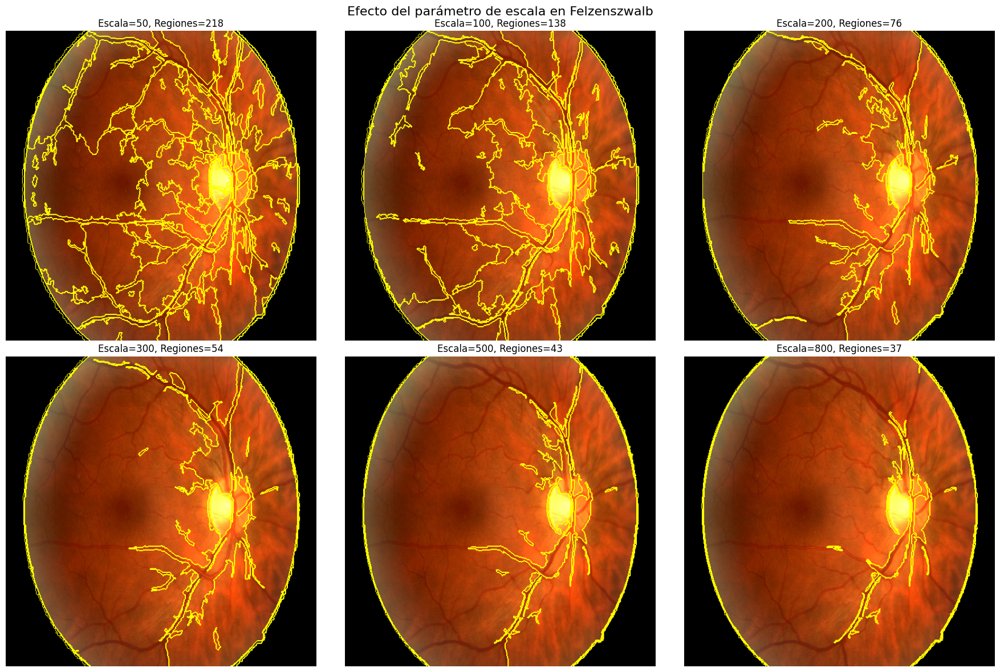

In [9]:
# 3.2 Felzenszwalb-Huttenlocher Segmentation

def apply_felzenszwalb(img, scale=100, sigma=0.5, min_size=50):
    """
    Aplica Felzenszwalb-Huttenlocher segmentation.
    
    Parámetros:
    - scale: Parámetro k - mayor k = segmentos más grandes
    - sigma: Suavizado gaussiano inicial
    - min_size: Tamaño mínimo de segmento
    """
    # Convertir a float
    img_float = img.astype(np.float64) / 255.0
    
    # Aplicar felzenszwalb
    segments = felzenszwalb(
        img_float,
        scale=scale,
        sigma=sigma,
        min_size=min_size,
        channel_axis=-1
    )
    
    return segments

# Aplicar con diferentes escalas
if img_rgb is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    scales = [50, 100, 200, 300, 500, 800]
    
    for idx, scale in enumerate(scales):
        row, col = idx // 3, idx % 3
        segments = apply_felzenszwalb(img_resized, scale=scale)
        n_regions = len(np.unique(segments))
        
        axes[row, col].imshow(mark_boundaries(img_resized, segments, color=(1, 1, 0)))
        axes[row, col].set_title(f'Escala={scale}, Regiones={n_regions}')
        axes[row, col].axis('off')
    
    plt.suptitle('Efecto del parámetro de escala en Felzenszwalb', fontsize=16)
    plt.tight_layout()
    plt.show()

### 3.3 Quickshift (Modo Seeking)

Quickshift es similar a Mean Shift clustering:

1. **Estimación de densidad**: Para cada píxel, calcula la distancia a todos los demás píxeles
2. **Parzen density estimation**: Estima la densidad de probabilidad usando un kernel
3. **Gradiente ascendente**: Asigna cada píxel al píxel vecino con mayor densidad
4. **Agrupamiento**: Conecta píxeles que apuntan al mismo modo local

Ventajas:
- Captura mejor la estructura jerárquica
- Menos sensible a parámetros que SLIC

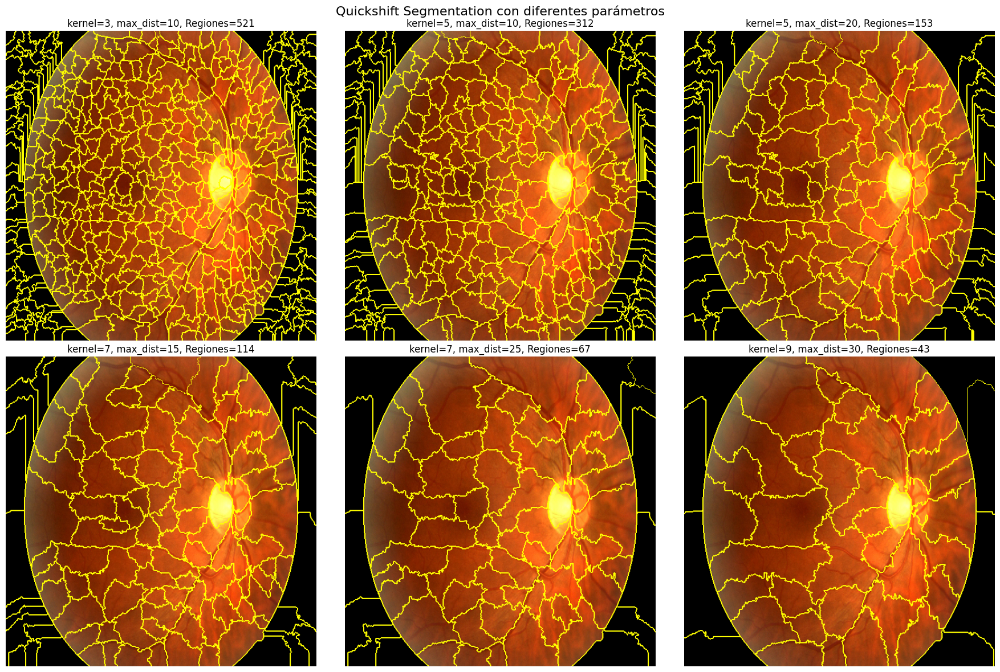

In [10]:
# 3.3 Quickshift Segmentation

def apply_quickshift(img, kernel_size=5, max_dist=10, ratio=0.5):
    """
    Aplica Quickshift segmentation.
    
    Parámetros:
    - kernel_size: Tamaño del kernel para estimación de densidad
    - max_dist: Distancia máxima para unir regiones
    - ratio: Proporción de带宽 usada para media
    """
    # Convertir a float
    img_float = img.astype(np.float64) / 255.0
    
    # Aplicar quickshift
    segments = quickshift(
        img_float,
        kernel_size=kernel_size,
        max_dist=max_dist,
        ratio=ratio,
        channel_axis=-1
    )
    
    return segments

# Aplicar con diferentes parámetros
if img_rgb is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    params = [
        (3, 10, 0.5),
        (5, 10, 0.5),
        (5, 20, 0.5),
        (7, 15, 0.5),
        (7, 25, 0.5),
        (9, 30, 0.5)
    ]
    
    for idx, (ks, md, ratio) in enumerate(params):
        row, col = idx // 3, idx % 3
        segments = apply_quickshift(img_resized, kernel_size=ks, max_dist=md, ratio=ratio)
        n_regions = len(np.unique(segments))
        
        axes[row, col].imshow(mark_boundaries(img_resized, segments, color=(1, 1, 0)))
        axes[row, col].set_title(f'kernel={ks}, max_dist={md}, Regiones={n_regions}')
        axes[row, col].axis('off')
    
    plt.suptitle('Quickshift Segmentation con diferentes parámetros', fontsize=16)
    plt.tight_layout()
    plt.show()

### 3.4 Watershed (Basado en Marcadores)

Watershed transforma la imagen en un relieve topográfico:

1. **Gradiente de imagen**: Calcula la magnitud del gradiente (bordes = montañas altas)
2. **Inundación**: "Llena" las cuencas desde los mínimos locales
3. **Líneas de Watershed**: Las fronteras entre regiones = líneas de partage d'eaux

Usando marcadores, podemos controlar dónde تبدأ/terminan las cuencas.

Número de regiones watershed: 2196


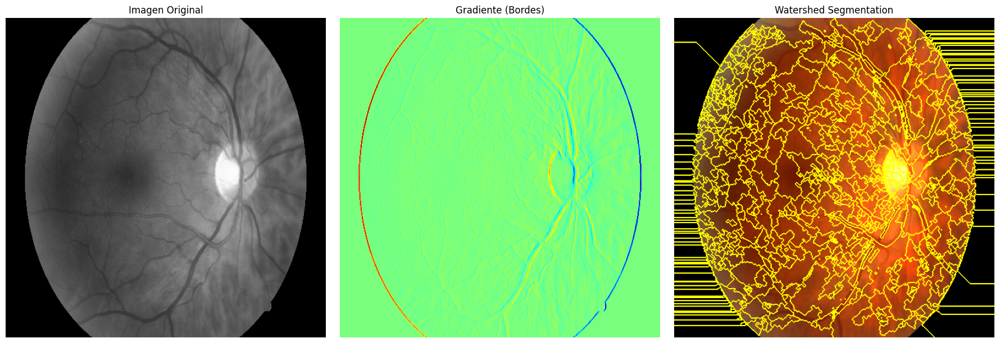

In [11]:
# 3.4 Watershed Segmentation

from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

def apply_watershed(img, markers=None, compactness=0.0):
    """
    Aplica Watershed segmentation.
    
    Si markers es None, usa marcadores automáticos basados en distancia.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    if markers is None:
        # Calcular distancia euclidiana desde el fondo
        distance = ndi.distance_transform_edt(gray)
        
        # Encontrar picos locales como marcadores
        local_max = peak_local_max(
            distance,
            min_distance=20,
            labels=gray
        )
        
        # Crear mapa de marcadores
        markers = np.zeros_like(gray, dtype=np.int32)
        for i, (y, x) in enumerate(local_max):
            markers[y, x] = i + 1
    
    # Calcular gradiente
    gradient = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)
    gradient = cv2.normalize(gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Aplicar watershed
    segments = watershed(gradient, markers=markers)
    
    return segments

# Aplicar watershed
if img_rgb is not None:
    segments_ws = apply_watershed(img_resized)
    
    print(f"Número de regiones watershed: {len(np.unique(segments_ws))}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    gradient = ndi.sobel(gray.astype(float))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    
    axes[1].imshow(gradient, cmap='jet')
    axes[1].set_title('Gradiente (Bordes)')
    axes[1].axis('off')
    
    axes[2].imshow(mark_boundaries(img_resized, segments_ws, color=(1, 1, 0)))
    axes[2].set_title('Watershed Segmentation')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Implementación Completa de SEM (Selective Search)

Ahora implementemos Selective Search completo usando OpenCV, que combina múltiples estrategias de segmentación jerárquica.

In [12]:
# 4. Selective Search usando OpenCV (implementación optimizada)

try:
    # OpenCV con selective search está disponible desde OpenCV 4.x
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    HAS_SELECTIVE_SEARCH = True
    print("Selective Search de OpenCV disponible")
except AttributeError:
    HAS_SELECTIVE_SEARCH = False
    print("Selective Search de OpenCV NO disponible - usando implementación alternativa")


def sem_selective_search(img, mode='fast', base_k=50, inc_k=50):
    """
    Implementación de Selective Search (SEM).
    
    Parámetros:
    - mode: 'fast' para versión rápida, 'quality' para mejor calidad
    - base_k: Número inicial de clusters
    - inc_k: Incremento en cada nivel jerárquico
    
    Retorna:
    - regions: Lista de bounding boxes [(x, y, w, h), ...]
    - segments: Máscara de segmentación
    """
    if HAS_SELECTIVE_SEARCH:
        ss.setBaseImage(img)
        
        if mode == 'fast':
            ss.switchToSingleStrategy()
            ss.switchToSelectiveSearchFast()
        else:
            ss.switchToSelectiveSearchQuality()
        
        regions = ss.process()
        
        return regions, None
    else:
        # Versión alternativa usando combinación de métodos
        return sem_custom_implementation(img, base_k=base_k, inc_k=inc_k)


def sem_custom_implementation(img, base_k=50, inc_k=50):
    """
    Implementación personalizada de Selective Search usando SLIC + Fusión jerárquica.
    """
    # Convertir a espacio de color apropiado
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    
    # Generar superpixels iniciales
    img_float = img.astype(np.float64) / 255.0
    segments = slic(img_float, n_segments=200, compactness=10.0, sigma=1, 
                    start_label=0, channel_axis=-1)
    
    # Calcular features para cada región
    regions = []
    for seg_id in np.unique(segments):
        mask = (segments == seg_id)
        ys, xs = np.where(mask)
        if len(ys) > 0:
            regions.append({
                'bbox': (xs.min(), ys.min(), xs.max() - xs.min(), ys.max() - ys.min()),
                'mean_color': img[mask].mean(axis=0),
                'size': mask.sum()
            })
    
    # Generar múltiples propuestas (simplificado)
    proposals = []
    for r in regions:
        proposals.append(r['bbox'])
    
    return np.array(proposals) if proposals else np.array([]), segments

Selective Search de OpenCV NO disponible - usando implementación alternativa


Número de propuestas de región: 182


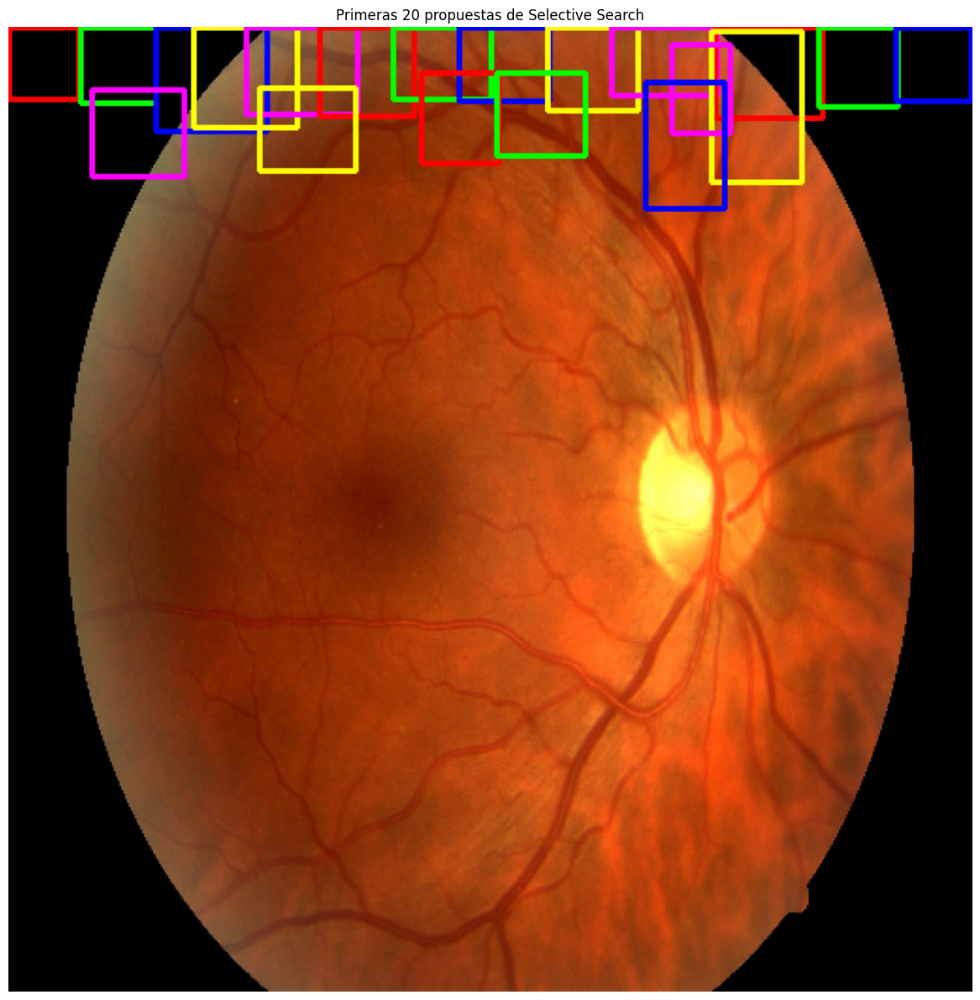

In [13]:
# Aplicar Selective Search
if img_rgb is not None:
    regions, segments = sem_selective_search(img_resized, mode='fast')
    
    print(f"Número de propuestas de región: {len(regions)}")
    
    # Mostrar algunas propuestas
    if len(regions) > 0:
        # Dibujar las primeras N propuestas
        n_show = min(20, len(regions))
        img_with_boxes = img_resized.copy()
        
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
        
        for i in range(n_show):
            x, y, w, h = regions[i]
            color = colors[i % len(colors)]
            cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), color, 2)
        
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(img_with_boxes)
        ax.set_title(f'Primeras {n_show} propuestas de Selective Search')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 5. Comparación de Métodos de Segmentación

Veamos una comparación lado a lado de todos los métodos.

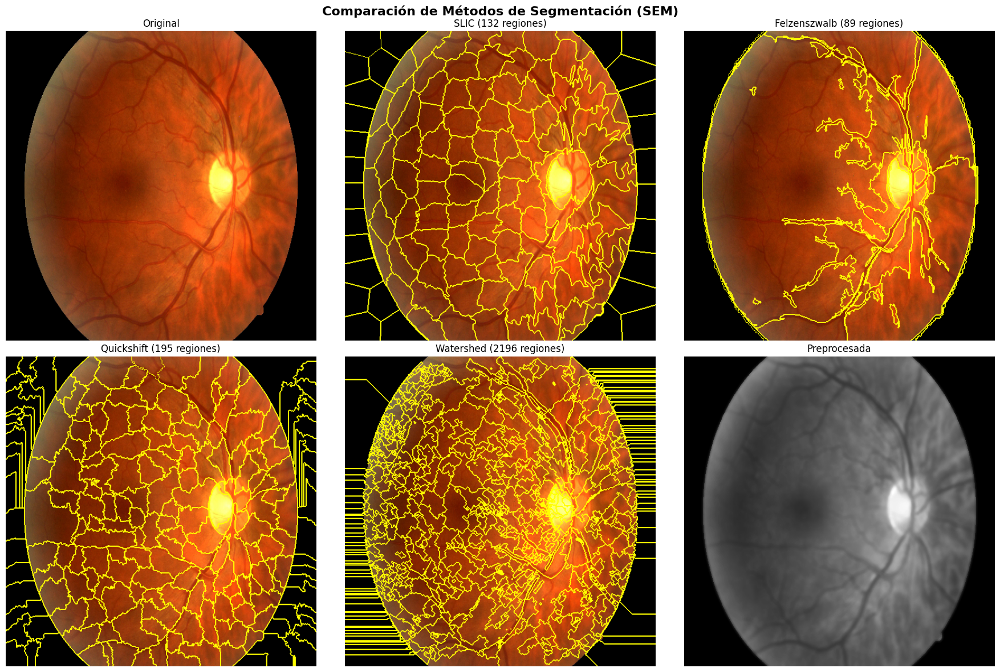

In [14]:
# Comparación de todos los métodos
if img_rgb is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original
    axes[0, 0].imshow(img_resized)
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    # SLIC
    seg_slic = apply_slic_superpixels(img_resized, n_segments=150)
    axes[0, 1].imshow(mark_boundaries(img_resized, seg_slic, color=(1, 1, 0)))
    axes[0, 1].set_title(f'SLIC ({len(np.unique(seg_slic))} regiones)')
    axes[0, 1].axis('off')
    
    # Felzenszwalb
    seg_fh = apply_felzenszwalb(img_resized, scale=150)
    axes[0, 2].imshow(mark_boundaries(img_resized, seg_fh, color=(1, 1, 0)))
    axes[0, 2].set_title(f'Felzenszwalb ({len(np.unique(seg_fh))} regiones)')
    axes[0, 2].axis('off')
    
    # Quickshift
    seg_qs = apply_quickshift(img_resized, kernel_size=5, max_dist=15)
    axes[1, 0].imshow(mark_boundaries(img_resized, seg_qs, color=(1, 1, 0)))
    axes[1, 0].set_title(f'Quickshift ({len(np.unique(seg_qs))} regiones)')
    axes[1, 0].axis('off')
    
    # Watershed
    seg_ws = apply_watershed(img_resized)
    axes[1, 1].imshow(mark_boundaries(img_resized, seg_ws, color=(1, 1, 0)))
    axes[1, 1].set_title(f'Watershed ({len(np.unique(seg_ws))} regiones)')
    axes[1, 1].axis('off')
    
    # Selective Search (si disponible)
    if HAS_SELECTIVE_SEARCH:
        ss_result, _ = sem_selective_search(img_resized, mode='fast')
        img_ss = img_resized.copy()
        for i, (x, y, w, h) in enumerate(ss_result[:10]):
            cv2.rectangle(img_ss, (x, y), (x + w, y + h), (0, 255, 0), 2)
        axes[1, 2].imshow(img_ss)
        axes[1, 2].set_title(f'Selective Search ({len(ss_result)} propuestas)')
    else:
        axes[1, 2].imshow(enhanced, cmap='gray')
        axes[1, 2].set_title('Preprocesada')
    axes[1, 2].axis('off')
    
    plt.suptitle('Comparación de Métodos de Segmentación (SEM)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Aplicación a Múltiples Imágenes

Veamos cómo funciona SEM en varias imágenes del dataset.

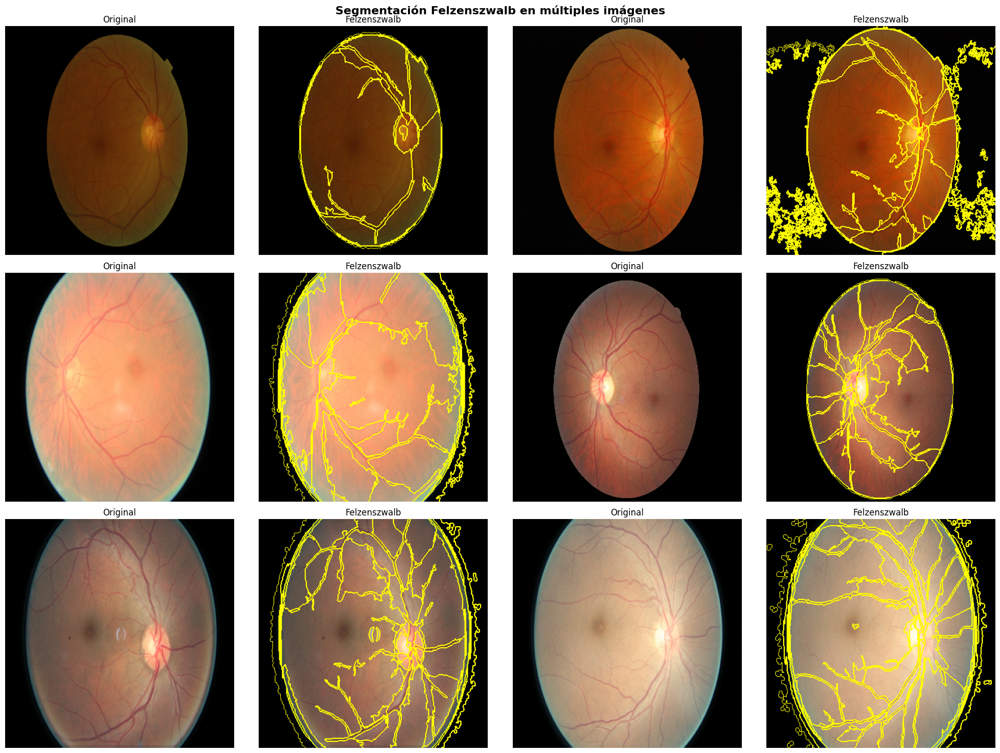

In [15]:
# Aplicar a múltiples imágenes
def segment_image_pipeline(img_path, method='slic', **kwargs):
    """
    Pipeline completo de segmentación para una imagen.
    
    Returns: imagen preprocesada, máscara de segmentación
    """
    # Cargar imagen
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, None
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (384, 384))
    
    # Seleccionar método
    if method == 'slic':
        segments = apply_slic_superpixels(img_resized, n_segments=kwargs.get('n_segments', 150))
    elif method == 'felzenszwalb':
        segments = apply_felzenszwalb(img_resized, scale=kwargs.get('scale', 150))
    elif method == 'quickshift':
        segments = apply_quickshift(img_resized, kernel_size=kwargs.get('kernel_size', 5),
                                    max_dist=kwargs.get('max_dist', 15))
    elif method == 'watershed':
        segments = apply_watershed(img_resized)
    else:
        raise ValueError(f"Método desconocido: {method}")
    
    return img_resized, segments

# Seleccionar algunas imágenes
sample_images = images[:6]  # Primeras 6 imágenes

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for idx, img_path in enumerate(sample_images):
    row, col = idx // 2, (idx % 2) * 2
    
    img_resized, segments = segment_image_pipeline(img_path, method='felzenszwalb', scale=100)
    
    if img_resized is not None:
        # Original
        axes[row, col].imshow(img_resized)
        axes[row, col].set_title(f'Original')
        axes[row, col].axis('off')
        
        # Segmentada
        axes[row, col + 1].imshow(mark_boundaries(img_resized, segments, color=(1, 1, 0)))
        axes[row, col + 1].set_title(f'Felzenszwalb')
        axes[row, col + 1].axis('off')

plt.suptitle('Segmentación Felzenszwalb en múltiples imágenes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Análisis de Regiones de Interés

Identifiquemos las regiones más significativas y analicemos sus propiedades.

Top 5 regiones más grandes:
------------------------------------------------------------
Región 1: Área=1817, Color Promedio=R:46.3 G:62.2 B:61.0
Región 2: Área=1176, Color Promedio=R:0.3 G:0.7 B:0.7
Región 3: Área=1157, Color Promedio=R:85.8 G:100.8 B:94.7
Región 4: Área=1114, Color Promedio=R:0.7 G:1.6 B:1.7
Región 5: Área=1087, Color Promedio=R:94.3 G:115.2 B:111.8


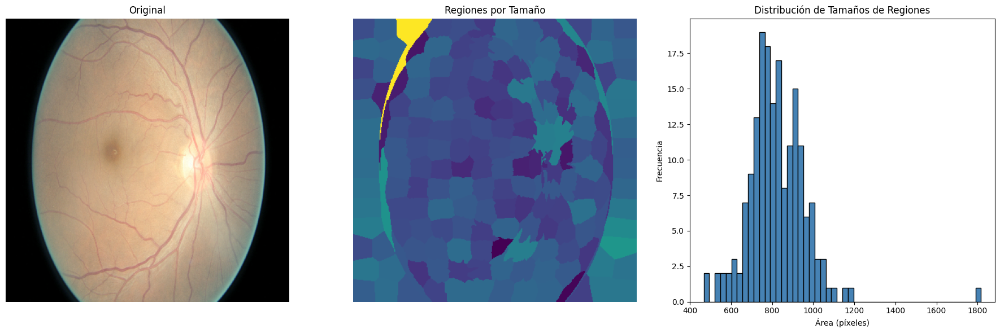

In [16]:
# Análisis de regiones
def analyze_segments(img, segments):
    """
    Analiza las regiones segmentadas y calcula estadísticas.
    """
    n_regions = len(np.unique(segments))
    
    region_stats = []
    
    for seg_id in np.unique(segments):
        mask = (segments == seg_id)
        
        # Propiedades de la región
        area = mask.sum()
        
        # Color promedio en RGB
        mean_color = img[mask].mean(axis=0)
        
        # Posición del centroide
        ys, xs = np.where(mask)
        centroid_y = ys.mean()
        centroid_x = xs.mean()
        
        region_stats.append({
            'id': seg_id,
            'area': area,
            'mean_color': mean_color,
            'centroid': (centroid_x, centroid_y),
            'bbox': (xs.min(), ys.min(), xs.max(), ys.max())
        })
    
    return region_stats

# Analizar segmentos
if img_rgb is not None:
    seg_slic = apply_slic_superpixels(img_resized, n_segments=200)
    stats = analyze_segments(img_resized, seg_slic)
    
    # Ordenar por área
    stats_sorted = sorted(stats, key=lambda x: x['area'], reverse=True)
    
    # Mostrar las 5 regiones más grandes
    print("Top 5 regiones más grandes:")
    print("-" * 60)
    for i, s in enumerate(stats_sorted[:5]):
        print(f"Región {i+1}: Área={s['area']}, Color Promedio=R:{s['mean_color'][0]:.1f} G:{s['mean_color'][1]:.1f} B:{s['mean_color'][2]:.1f}")
    
    # Visualizar las regiones más grandes
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Crear mapa de colores por área
    areas = np.array([s['area'] for s in stats])
    areas_normalized = (areas - areas.min()) / (areas.max() - areas.min())
    
    color_map = plt.cm.viridis(areas_normalized[seg_slic])
    
    axes[0].imshow(img_resized)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(color_map)
    axes[1].set_title('Regiones por Tamaño')
    axes[1].axis('off')
    
    # Histograma de tamaños
    axes[2].hist(areas, bins=50, color='steelblue', edgecolor='black')
    axes[2].set_xlabel('Área (píxeles)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].set_title('Distribución de Tamaños de Regiones')
    
    plt.tight_layout()
    plt.show()

## 8. Resumen y Conclusiones

### Métodos de Segmentación Implementados (SEM):

| Método | Complejidad | Velocidad | Características |
|--------|-------------|------------|------------------|
| **SLIC** | O(N·k·iter) | Rápido | Superpixels uniformes, bueno para preprocesamiento |
| **Felzenszwalb** | O(N log N) | Muy Rápido | Segmentación basada en grafos, escala adaptable |
| **Quickshift** | O(N²) | Medio | Captura jerarquía, sensible a outliers |
| **Watershed** | O(N log N) | Medio | Basado en marcadores, bueno para detectar bordes |
| **Selective Search** | Variable | Rápido/Q | Múltiples escalas, propuestas de objetos |

### Recomendaciones para Imágenes Retinales:

1. **Para preprocesamiento general**: SLIC o Felzenszwalb con k=100-200
2. **Para detectar lesiones**: Watershed con marcadores bien definidos
3. **Para análisis multi-escala**: Selective Search
4. **Parámetros importantes**:
   - `scale` en Felzenszwalb: mayor = regiones más grandes
   - `n_segments` en SLIC: controla granularidad
   - `max_dist` en Quickshift: distancia máxima de fusión

### Próximos Pasos:

- Combinar segmentación con extracción de características
- Usar segmentación como entrada para modelos de clasificación
- Implementar post-procesamiento morfológico

In [17]:
print("¡Notebook de Segmentación SEM completado!")
print("\nPara usar este código:")
print("1. Asegúrate de tener las dependencias: scikit-image, opencv-python")
print("2. Las imágenes deben estar en la carpeta 'data/'")
print("3. Ajusta los parámetros según tus necesidades")

¡Notebook de Segmentación SEM completado!

Para usar este código:
1. Asegúrate de tener las dependencias: scikit-image, opencv-python
2. Las imágenes deben estar en la carpeta 'data/'
3. Ajusta los parámetros según tus necesidades
